# Model comparison and results

This notebook compares the performance and size of all CIFAR-10 models trained in previous notebooks:
- **01-DNN**: Fully connected deep neural network
- **02-CNN**: Convolutional neural network (grayscale)
- **03-RGB-CNN**: Convolutional neural network (RGB)
- **04-architecture_optimization**: Optuna-optimized CNN architecture
- **05-training-optimization**: Optimized training hyperparameters
- **06-augmented-CNN**: CNN trained with data augmentation
- **07-resnet50**: Transfer learning with ResNet50

## Notebook setup

### Imports

In [1]:
# Standard library imports
import json
import pickle
import time

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

from torchvision import datasets, transforms

# Package imports
import image_classification_tools.pytorch.plotting as plots

# Local imports
import configuration as config

Using device: cuda


## 1. Load model metadata

In [2]:
# Load model configurations from JSON
with open(config.MODELS_DIR / 'models_config.json', 'r') as f:
    models_metadata = json.load(f)['models']

print(f'Loaded metadata for {len(models_metadata)} models')

Loaded metadata for 7 models


### Prepare test samples

In [3]:
# Prepare test samples for cold start testing
grayscale_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
rgb_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

grayscale_dataset = datasets.CIFAR10(root=config.DATA_DIR, train=False, transform=grayscale_transform)
rgb_dataset = datasets.CIFAR10(root=config.DATA_DIR, train=False, transform=rgb_transform)

grayscale_sample, _ = grayscale_dataset[0]
rgb_sample, _ = rgb_dataset[0]

## 2. Measure cold start times

In [4]:
cold_start_times = {}

for model_info in models_metadata:

    model_name = model_info['name']
    model_path = config.MODELS_DIR / model_info['model_file']
    
    if not model_path.exists():
        print(f'Skipping {model_name} - model file not found')
        continue
    
    # Select appropriate test sample
    sample = grayscale_sample if model_info['input_type'] == 'grayscale' else rgb_sample
    sample_batch = sample.unsqueeze(0)
    
    # Measure cold start time (average over 5 runs)
    times = []

    for _ in range(5):

        start_time = time.time()
        
        # Load model from disk (weights_only=False for models saved with torch.save(model))
        loaded = torch.load(model_path, map_location=config.DEVICE, weights_only=False)
        
        # Check if it's a state dict or full model
        if isinstance(loaded, dict):
            print(f'Skipping {model_name} - saved as state_dict (not full model)')
            break
        
        model = loaded
        model.to(config.DEVICE)
        model.eval()
        
        # Make single prediction
        with torch.no_grad():
            _ = model(sample_batch.to(config.DEVICE))
        
        times.append(time.time() - start_time)
        
        # Clean up
        del model

        if torch.cuda.is_available():
            torch.cuda.empty_cache()
    
    # Only record if we successfully measured
    if times:
        cold_start_times[model_name] = np.mean(times)
        print(f'{model_name}: {cold_start_times[model_name]*1000:.2f} ms')

print(f'\nCold start measurement complete for {len(cold_start_times)} models')

DNN: 57.77 ms
Gray CNN: 47.36 ms
RGB CNN: 9.39 ms
Arch-Opt CNN: 69.12 ms
Train-Opt CNN: 37.65 ms
Aug CNN: 41.23 ms
ResNet50: 168.09 ms

Cold start measurement complete for 7 models


## 3. Measure average inference rate

In [5]:
inference_rates = {}
n_samples = 1000

for model_info in models_metadata:

    model_name = model_info['name']
    model_path = config.MODELS_DIR / model_info['model_file']
    
    if not model_path.exists():
        print(f'Skipping {model_name} - model file not found')
        continue
    
    # Load appropriate dataset
    dataset = grayscale_dataset if model_info['input_type'] == 'grayscale' else rgb_dataset
    
    # Load model
    loaded = torch.load(model_path, map_location=config.DEVICE, weights_only=False)
    
    # Check if it's a state dict or full model
    if isinstance(loaded, dict):
        print(f'Skipping {model_name} - saved as state_dict (not full model)')
        continue
    
    model = loaded
    model.to(config.DEVICE)
    model.eval()
    
    # Prepare batch of samples
    samples = []

    for i in range(n_samples):
        img, _ = dataset[i]
        samples.append(img)
    
    batch = torch.stack(samples).to(config.DEVICE)
    
    # Warm up
    with torch.no_grad():
        _ = model(batch[:10])
    
    # Measure inference time
    start_time = time.time()
    
    with torch.no_grad():
        _ = model(batch)
    
    elapsed_time = time.time() - start_time
    
    # Calculate images per second
    inference_rate = n_samples / elapsed_time
    inference_rates[model_name] = inference_rate
    
    print(f'{model_name}: {inference_rate:.2f} images/sec ({elapsed_time*1000/n_samples:.2f} ms/image)')
    
    # Clean up
    del model, batch

    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\nInference rate measurement complete for {len(inference_rates)} models')

DNN: 128356.46 images/sec (0.01 ms/image)
Gray CNN: 36065.14 images/sec (0.03 ms/image)
RGB CNN: 272995.57 images/sec (0.00 ms/image)
Arch-Opt CNN: 7905.96 images/sec (0.13 ms/image)
Train-Opt CNN: 35796.74 images/sec (0.03 ms/image)
Aug CNN: 155586.62 images/sec (0.01 ms/image)
ResNet50: 22658.32 images/sec (0.04 ms/image)

Inference rate measurement complete for 7 models


## 4. Load performance results from disk

In [6]:
results = []

for model_info in models_metadata:

    model_name = model_info['name']
    results_path = config.RESULTS_DIR / model_info['results_file']
    
    if not results_path.exists():
        print(f"Skipping {model_name} - results file not found")
        continue
    
    # Load saved test results
    with open(results_path, 'rb') as f:
        data = pickle.load(f)
    
    # Calculate model size (4 bytes per float32 parameter)
    model_size_mb = (data['total_params'] * 4) / (1024 ** 2)
    
    # Compile results
    results.append({
        'Model': model_name,
        'Description': model_info['description'],
        'Total parameters': data['total_params'],
        'Trainable parameters': data['trainable_params'],
        'Size (MB)': model_size_mb,
        'Test accuracy (%)': data['test_accuracy'],
        'Cold start (ms)': cold_start_times.get(model_name, 0) * 1000,
        'Inference rate (img/s)': inference_rates.get(model_name, 0),
        'true_labels': np.array(data['true_labels']),
        'predictions': np.array(data['predictions']),
        'all_probs': np.array(data['all_probs'])
    })

print(f'Loaded results for {len(results)} models')

Loaded results for 7 models


## 5. Results summary

In [7]:
# Create summary dataframe
summary_df = pd.DataFrame([
    {
        'Model': r['Model'],
        'Description': r['Description'],
        'Parameters': f"{r['Total parameters']:,}",
        'Size (MB)': f"{r['Size (MB)']:.2f}",
        'Accuracy (%)': f"{r['Test accuracy (%)']:.2f}",
        'Cold start (ms)': f"{r['Cold start (ms)']:.2f}",
        'Inference (img/s)': f"{r['Inference rate (img/s)']:.2f}"
    }
    for r in results
])

summary_df

,Model,Description,Parameters,Size (MB),Accuracy (%),Cold start (ms),Inference (img/s)
0,DNN,Fully connected deep neural network,"1,329,098",5.07,47.47,57.77,128356.46
1,Gray CNN,CNN on grayscale images,"15,210",0.06,57.91,47.36,36065.14
2,RGB CNN,CNN on RGB images,"15,786",0.06,66.08,9.39,272995.57
3,Arch-Opt CNN,Optuna-optimized CNN architecture,"1,920,970",7.33,88.47,69.12,7905.96
4,Train-Opt CNN,Optimized training hyperparameters,"1,920,970",7.33,89.96,37.65,35796.74
5,Aug CNN,CNN with data augmentation,"1,920,970",7.33,90.65,41.23,155586.62
6,ResNet50,Transfer learning with ResNet50,"23,520,906",89.73,92.50,168.09,22658.32


## 6. Performance visualizations

### Model performance metrics

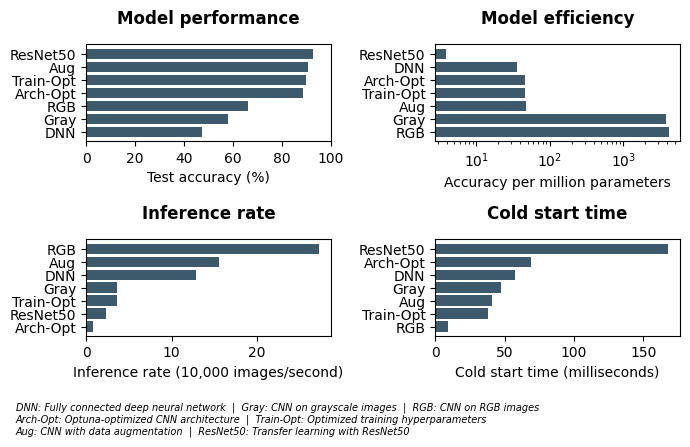

In [8]:
# Create a 2x2 subplot figure with all performance metrics
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(7, 4))

# Helper to shorten model names for display
def short_name(name):
    return name.replace(' CNN', '')

# 1. Model performance comparison (Accuracy)
ax1.set_title('Model performance', fontweight='bold', fontsize=12, pad=15)
sorted_results = sorted(results, key=lambda x: x['Test accuracy (%)'])
models_acc = [short_name(r['Model']) for r in sorted_results]
accuracies = [r['Test accuracy (%)'] for r in sorted_results]
bars1 = ax1.barh(models_acc, accuracies, color='#3d5a6c')

ax1.set_xlabel('Test accuracy (%)')
ax1.set_xlim(0, 100)

# 2. Model efficiency comparison
ax2.set_title('Model efficiency', fontweight='bold', fontsize=12, pad=15)

efficiency_results = []

for r in results:
    params_millions = r['Total parameters'] / 1e6
    efficiency = r['Test accuracy (%)'] / params_millions
    efficiency_results.append({
        'Model': r['Model'],
        'Accuracy/parameter (M)': efficiency
    })

efficiency_results = sorted(
    efficiency_results,
    key=lambda x: x['Accuracy/parameter (M)'],
    reverse=True
)

models_eff = [short_name(r['Model']) for r in efficiency_results]
efficiencies = [r['Accuracy/parameter (M)'] for r in efficiency_results]
bars2 = ax2.barh(models_eff, efficiencies, color='#3d5a6c')

ax2.set_xscale('log')
ax2.set_xlabel('Accuracy per million parameters')

# 3. Inference rate comparison
ax3.set_title('Inference rate', fontweight='bold', fontsize=12, pad=15)
sorted_by_inference = sorted(results, key=lambda x: x['Inference rate (img/s)'])
models_inf = [short_name(r['Model']) for r in sorted_by_inference]
inference_rates_list = [r['Inference rate (img/s)'] / 10000 for r in sorted_by_inference]
bars3 = ax3.barh(models_inf, inference_rates_list, color='#3d5a6c')

ax3.set_xlabel('Inference rate (10,000 images/second)')

# 4. Cold start time comparison
ax4.set_title('Cold start time', fontweight='bold', fontsize=12, pad=15)
sorted_by_cold_start = sorted(results, key=lambda x: x['Cold start (ms)'])
models_cold = [short_name(r['Model']) for r in sorted_by_cold_start]
cold_start_list = [r['Cold start (ms)'] for r in sorted_by_cold_start]
bars4 = ax4.barh(models_cold, cold_start_list, color='#3d5a6c')

ax4.set_xlabel('Cold start time (milliseconds)')

# Add figure legend (split into 3 lines)
legend_items = [f"{short_name(r['Model'])}: {r['Description']}" for r in results]
legend_text = '  |  '.join(legend_items[:3]) + '\n' + '  |  '.join(legend_items[3:5]) + '\n' + '  |  '.join(legend_items[5:])
fig.text(0.03, -0.10, legend_text, ha='left', fontsize=7, style='italic')

plt.tight_layout()
plt.savefig(config.DOCS_DIR / 'assets' / 'model_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Per-class performance analysis

In [9]:
# Calculate per-class accuracy for each model
class_accuracies = {}

# Helper to shorten model names for display
def short_name(name):
    return name.replace(' CNN', '')

for r in results:
    true = r['true_labels']
    pred = r['predictions']
    
    # Calculate accuracy for each class
    class_acc = []

    for i in range(10):
        mask = (true == i)

        if mask.sum() > 0:
            acc = (pred[mask] == i).sum() / mask.sum() * 100
            class_acc.append(acc)

        else:
            class_acc.append(0)
    

    class_accuracies[short_name(r['Model'])] = class_acc

# Create dataframe
class_acc_df = pd.DataFrame(class_accuracies, index=config.CLASS_NAMES)

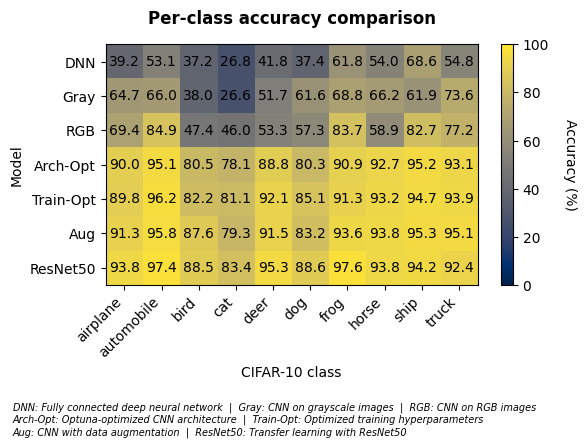

In [10]:
# Create heatmap
fig, ax = plt.subplots(figsize=(6, 4))

ax.set_title('Per-class accuracy comparison', fontweight='bold', fontsize=12, pad=15)

im = ax.imshow(class_acc_df.T, cmap='cividis', aspect='auto', vmin=0, vmax=100)

# Set ticks and labels
ax.set_xticks(np.arange(len(config.CLASS_NAMES)))
ax.set_yticks(np.arange(len(results)))
ax.set_xticklabels(config.CLASS_NAMES, rotation=45, ha='right')
ax.set_yticklabels([short_name(r['Model']) for r in results])

# Add colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Accuracy (%)', rotation=270, labelpad=20)

# Add text annotations
for i in range(len(results)):
    for j in range(len(config.CLASS_NAMES)):
        ax.text(j, i, f'{class_acc_df.iloc[j, i]:.1f}',
                ha='center', va='center', color='black')

ax.set_xlabel('CIFAR-10 class')
ax.set_ylabel('Model')

# Add figure legend (split into 3 lines)
legend_items = [f"{short_name(r['Model'])}: {r['Description']}" for r in results]
legend_text = '  |  '.join(legend_items[:3]) + '\n' + '  |  '.join(legend_items[3:5]) + '\n' + '  |  '.join(legend_items[5:])
fig.text(0.03, -0.10, legend_text, ha='left', fontsize=7, style='italic')

plt.tight_layout()
plt.savefig(config.DOCS_DIR / 'assets' / 'per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Confusion matrix comparison

Worst model: DNN - Accuracy: 47.47%


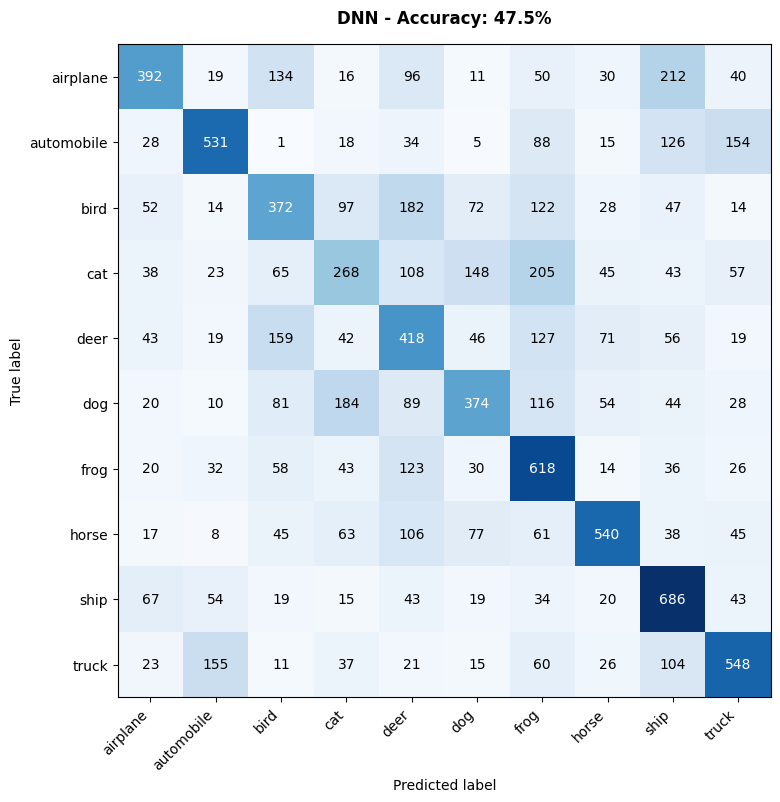


Best model: ResNet50 - Accuracy: 92.50%


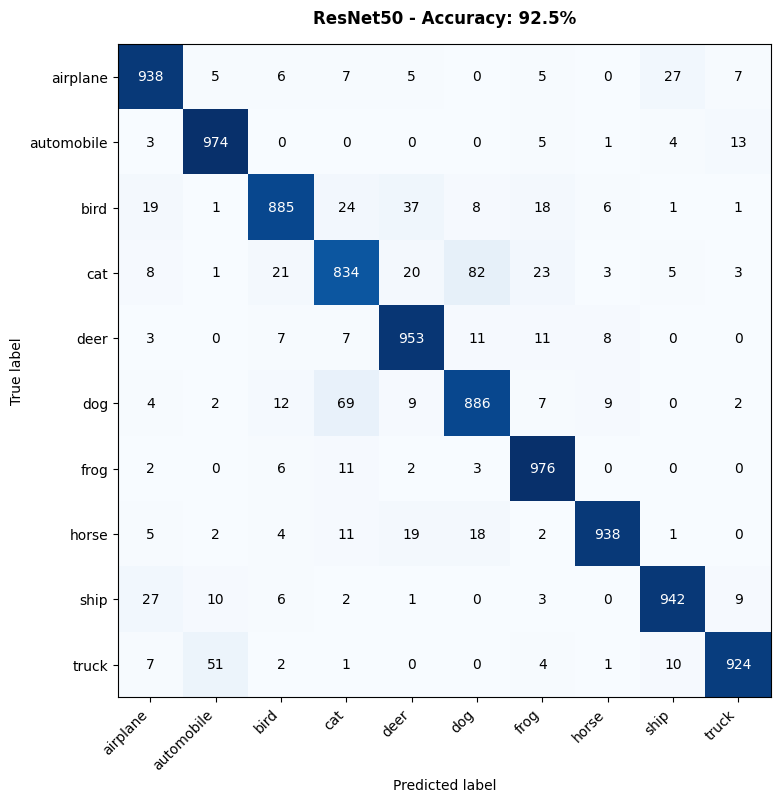

In [11]:
# Find best and worst models by accuracy
sorted_by_acc = sorted(results, key=lambda x: x['Test accuracy (%)'])
worst_model = sorted_by_acc[0]
best_model = sorted_by_acc[-1]

# Plot confusion matrix for worst model
print(f"Worst model: {worst_model['Model']} - Accuracy: {worst_model['Test accuracy (%)']:.2f}%")

fig1, ax1 = plots.plot_confusion_matrix(
    worst_model['true_labels'], 
    worst_model['predictions'], 
    config.CLASS_NAMES,
    figsize=(8, 8)
)

ax1.set_title(
    f'{worst_model["Model"]} - Accuracy: {worst_model["Test accuracy (%)"]:.1f}%', 
    fontsize=12, fontweight='bold', pad=15
)

plt.show()

# Plot confusion matrix for best model
print(f"\nBest model: {best_model['Model']} - Accuracy: {best_model['Test accuracy (%)']:.2f}%")

fig2, ax2 = plots.plot_confusion_matrix(
    best_model['true_labels'], 
    best_model['predictions'], 
    config.CLASS_NAMES,
    figsize=(8, 8)
)

ax2.set_title(
    f'{best_model["Model"]} - Accuracy: {best_model["Test accuracy (%)"]:.1f}%', 
    fontsize=12, fontweight='bold', pad=15
)

plt.show()
